# K-means Cluster Heatmaps

In [77]:
import pandas as pd

expression = pd.read_csv("expression.txt", sep="\t")
expression = expression.set_index("Hugo_Symbol")
expression = expression.drop("Entrez_Gene_Id", axis=1)
# print(expression.head())

In [3]:
# patients = pd.read_csv("patient_bchm_recurr_cohorts.csv")
# print(patients.head())
# print()
# bchm_early_pts = patients[patients["Days to Bchm Recurr"]<100]
# bchm_late_pts = patients[patients["Days to Bchm Recurr"]>100]
# bchem_early_ids = bchm_early_pts["Patient (Firehose)"].to_list()
# bchem_late_ids = bchm_late_pts["Patient (Firehose)"].to_list()
# print(bchem_early_ids)
# print()
# print(bchem_late_ids)

In [178]:
import pandas as pd

# Load the data
df = pd.read_csv("prad_tcga_clinical_data.tsv", sep="\t")
print(df.columns)

df = df.rename(columns={
    'Patient ID': 'PATIENT_ID',
    'Days to Sample Collection.': 'DAYS_TO_SAMPLE_COLLECTION'
})

df = df[['PATIENT_ID', 'DAYS_TO_SAMPLE_COLLECTION']].copy()

# Define the cohort assignment function
def assign_cohort(days):
    if pd.isna(days):
        return None
    if days < 150:
        return 1
    elif days < 340:
        return 2
    elif days < 925:
        return 3
    elif days < 2000:
        return 4
    else:
        return 5

# Apply the function
df['BCHEM_COHORT'] = df['DAYS_TO_SAMPLE_COLLECTION'].apply(assign_cohort)

# Save to CSV
df.to_csv("5_bchem_cohorts.csv", index=False)

# Optional: preview
print(df.head())


Index(['Study ID', 'Patient ID', 'Sample ID', 'Diagnosis Age',
       'Neoplasm Disease Stage American Joint Committee on Cancer Code',
       'American Joint Committee on Cancer Publication Version Type',
       'Biochemical Recurrence Indicator', 'Bone Scan Result', 'Cancer Type',
       'Cancer Type Detailed', 'Cause of death source',
       'Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage',
       'Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage',
       'Neoplasm American Joint Committee on Cancer Clinical Primary Tumor T Stage',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage',
       'Ct scan ab pelvis indicator', 'Ct scan ab pelvis results',
       'Days to biochemical recurrence first', 'Days to bone Scan performed',
       'Days to Sample Collection.', 'Days to ct scan ab pelvis',
       'Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value',
       'Days to mri', 'Days

In [ ]:
patients = pd.read_csv("bchem_cohorts.csv")
print(patients.head())
print()
bchem_c1 = patients[patients["BCHEM_COHORT"]==1]
bchem_c2 = patients[patients["BCHEM_COHORT"]==2]
bchem_c3 = patients[patients["BCHEM_COHORT"]==3]
bchem_c4 = patients[patients["BCHEM_COHORT"]==4]

patients_for_c5 = pd.read_csv("5_bchem_cohorts.csv")
bchem_c5 = patients_for_c5[patients_for_c5["BCHEM_COHORT"]==5]

bchem_c1_ids = bchem_c1["PATIENT_ID"].to_list()
bchem_c2_ids = bchem_c2["PATIENT_ID"].to_list()
bchem_c3_ids = bchem_c3["PATIENT_ID"].to_list()
bchem_c4_ids = bchem_c4["PATIENT_ID"].to_list()
bchem_c5_ids = bchem_c5["PATIENT_ID"].to_list()
print(len(bchem_c1_ids))
print(len(bchem_c2_ids))
print(len(bchem_c3_ids))
print(len(bchem_c4_ids))
print(len(bchem_c5_ids))

# print(bchem_c4_ids)

     PATIENT_ID  DAYS_TO_BIOCHEMICAL_RECURRENCE_FIRST  BCHEM_COHORT
0  TCGA-ZG-A9L9                                    51             1
1  TCGA-EJ-A65F                                    75             1
2  TCGA-YL-A9WJ                                    76             1
3  TCGA-EJ-5504                                    77             1
4  TCGA-J4-AATZ                                    79             1

18
17
17
18
39
['TCGA-KK-A6E0', 'TCGA-V1-A8MM', 'TCGA-YL-A9WK', 'TCGA-KC-A4BR', 'TCGA-KK-A8IC', 'TCGA-YL-A8HO', 'TCGA-KK-A8I7', 'TCGA-KK-A7AY', 'TCGA-KK-A8I4', 'TCGA-VP-A87D', 'TCGA-KK-A7AQ', 'TCGA-KC-A4BV', 'TCGA-G9-6498', 'TCGA-YL-A8HK', 'TCGA-YL-A8SI', 'TCGA-YL-A9WX', 'TCGA-G9-6339', 'TCGA-EJ-8469']


In [66]:
# early_bchem = expression[expression.columns.intersection(bchem_early_ids)]
# early_bchem = early_bchem.dropna(axis=0)
# late_bchem = expression[expression.columns.intersection(bchem_late_ids)]
# late_bchem = late_bchem.dropna(axis=0)
# print(early_bchem.head())
# print()
# print(late_bchem.head())

In [78]:
print(expression.columns[:5])
print(bchem_c1_ids[:5])

expression.columns = expression.columns.str[:12]
bchem_c1_ids = [x[:12] for x in bchem_c1_ids]

print("Matches in cohort 1:", expression.columns.intersection(bchem_c1_ids).tolist())


Index(['TCGA-2A-A8VL', 'TCGA-2A-A8VO', 'TCGA-2A-A8VT', 'TCGA-2A-A8VV',
       'TCGA-2A-A8VX'],
      dtype='object')
['TCGA-ZG-A9L9', 'TCGA-EJ-A65F', 'TCGA-YL-A9WJ', 'TCGA-EJ-5504', 'TCGA-J4-AATZ']
Matches in cohort 1: ['TCGA-EJ-5504', 'TCGA-EJ-5519', 'TCGA-EJ-7783', 'TCGA-EJ-A65F', 'TCGA-EJ-A8FP', 'TCGA-J4-AATZ', 'TCGA-J9-A52B', 'TCGA-J9-A52E', 'TCGA-J9-A8CL', 'TCGA-V1-A8WW', 'TCGA-V1-A9O5', 'TCGA-V1-A9OL', 'TCGA-V1-A9ZI', 'TCGA-VP-A878', 'TCGA-XK-AAJR', 'TCGA-YJ-A8SW', 'TCGA-YL-A9WJ', 'TCGA-ZG-A9L9']


In [97]:
expression = expression.loc[:, ~expression.columns.duplicated()]

c1_bchem = expression[expression.columns.intersection(bchem_c1_ids)]
c1_bchem = c1_bchem.dropna(axis=0)

c2_bchem = expression[expression.columns.intersection(bchem_c2_ids)]
c2_bchem = c2_bchem.dropna(axis=0)

c3_bchem = expression[expression.columns.intersection(bchem_c3_ids)]
c3_bchem = c3_bchem.dropna(axis=0)

c4_bchem = expression[expression.columns.intersection(bchem_c4_ids)]
c4_bchem = c4_bchem.dropna(axis=0)

c5_bchem = expression[expression.columns.intersection(bchem_c5_ids)]
c5_bchem = c5_bchem.dropna(axis=0)

print(c1_bchem.head())
print()
print(c2_bchem.head())
print()
print(c3_bchem.head())
print()
print(c4_bchem.head())

             TCGA-EJ-5504  TCGA-EJ-5519  TCGA-EJ-7783  TCGA-EJ-A65F  \
Hugo_Symbol                                                           
UBE2Q2P2          -0.5443        0.0453       -0.0651        0.9005   
SSX9              -0.0474       -0.0474       -0.0474       -0.0474   
EZHIP             -0.0684       -0.5459       -0.2836       -0.7616   
EFCAB8            -0.4290       -0.1805       -0.4290       -0.2365   
SDR16C6P          -0.1839       -0.1839       -0.1839       -0.1839   

             TCGA-EJ-A8FP  TCGA-J4-AATZ  TCGA-J9-A52B  TCGA-J9-A52E  \
Hugo_Symbol                                                           
UBE2Q2P2           5.1367        1.9077       -0.7704       -0.6849   
SSX9              -0.0474       -0.0474       -0.0474       -0.0474   
EZHIP              0.7517       -0.7616       -0.3635        2.6624   
EFCAB8            -0.2111        0.6982        0.2590       -0.4290   
SDR16C6P          -0.1839       -0.1839       -0.1839       -0.1839   

    

In [92]:
print(c1_bchem.dtypes)

TCGA-EJ-5504    float64
TCGA-EJ-5519    float64
TCGA-EJ-7783    float64
TCGA-EJ-A65F    float64
TCGA-EJ-A8FP    float64
TCGA-J4-AATZ    float64
TCGA-J9-A52B    float64
TCGA-J9-A52E    float64
TCGA-J9-A8CL    float64
TCGA-V1-A8WW    float64
TCGA-V1-A9O5    float64
TCGA-V1-A9O5    float64
TCGA-V1-A9OL    float64
TCGA-V1-A9ZI    float64
TCGA-VP-A878    float64
TCGA-XK-AAJR    float64
TCGA-YJ-A8SW    float64
TCGA-YL-A9WJ    float64
TCGA-ZG-A9L9    float64
dtype: object


In [91]:
print("Are columns unique?", c1_bchem.columns.is_unique)
print("Sample row dtype:", c1_bchem.iloc[0].dtype)
print("DataFrame dtypes:\n", c1_bchem.dtypes)

Are columns unique? False
Sample row dtype: float64
DataFrame dtypes:
 TCGA-EJ-5504    float64
TCGA-EJ-5519    float64
TCGA-EJ-7783    float64
TCGA-EJ-A65F    float64
TCGA-EJ-A8FP    float64
TCGA-J4-AATZ    float64
TCGA-J9-A52B    float64
TCGA-J9-A52E    float64
TCGA-J9-A8CL    float64
TCGA-V1-A8WW    float64
TCGA-V1-A9O5    float64
TCGA-V1-A9O5    float64
TCGA-V1-A9OL    float64
TCGA-V1-A9ZI    float64
TCGA-VP-A878    float64
TCGA-XK-AAJR    float64
TCGA-YJ-A8SW    float64
TCGA-YL-A9WJ    float64
TCGA-ZG-A9L9    float64
dtype: object


In [104]:
import numpy as np
import pandas as pd
# outliers adjustment code using IQR method (can't use mean method because of large outliers)

# def replace_row_outliers_with_median(df: pd.DataFrame, threshold: float = 1):
#     df_clean = df.copy()
#     for index, row in df.iterrows():
#         Q1 = row.quantile(0.25)
#         Q3 = row.quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - threshold * IQR
#         upper_bound = Q3 + threshold * IQR
#         median = row.median()
#         outliers = (row < lower_bound) | (row > upper_bound)
#         # Now update only the outlier *values* in the row
#         for col in df.columns:
#             # print(f"row[col] type: {type(row[col])}, value: {row[col]}")
#             if row[col] < lower_bound or row[col] > upper_bound:
#                 df_clean.at[index, col] = median
#     return df_clean


def replace_outliers_vectorized(df: pd.DataFrame, threshold: float = 1):
    df_clean = df.copy()

    # Convert df to NumPy array for speed
    data = df_clean.to_numpy()

    # Compute IQR-based bounds row-wise
    Q1 = np.quantile(data, 0.25, axis=1)
    Q3 = np.quantile(data, 0.75, axis=1)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    medians = np.median(data, axis=1)

    # Build mask of outliers
    outliers = (data < lower_bound[:, np.newaxis]) | (data > upper_bound[:, np.newaxis])

    # Replace outliers with row-wise medians
    data[outliers] = np.broadcast_to(medians[:, np.newaxis], data.shape)[outliers]

    # Convert back to DataFrame
    return pd.DataFrame(data, index=df.index, columns=df.columns)

# adjusted_c1 = replace_row_outliers_with_median(c1_bchem)
# adjusted_c2 = replace_row_outliers_with_median(c2_bchem)
# adjusted_c3 = replace_row_outliers_with_median(c3_bchem)
# adjusted_c4 = replace_row_outliers_with_median(c4_bchem)
# adjusted_c5 = replace_row_outliers_with_median(c5_bchem)

adjusted_c1 = replace_outliers_vectorized(c1_bchem)
adjusted_c2 = replace_outliers_vectorized(c2_bchem)
adjusted_c3 = replace_outliers_vectorized(c3_bchem)
adjusted_c4 = replace_outliers_vectorized(c4_bchem)
adjusted_c5 = replace_outliers_vectorized(c5_bchem)


# print(adjusted_c1.head())


In [ ]:
# print(c1_bchem.loc["CPLX2"])
# sns.barplot(c1_bchem.loc["CPLX2"])
# print(adjusted_c1.loc["CPLX2"])
# sns.barplot(adjusted_c1.loc["CPLX2"])

In [105]:
adjusted_c1["c1 Average"] = adjusted_c1.mean(axis=1)
# print(early_bchem.head())
adjusted_c2["c2 Average"] = adjusted_c2.mean(axis=1)
# print(late_bchem.head())
adjusted_c3["c3 Average"] = adjusted_c3.mean(axis=1)
adjusted_c4["c4 Average"] = adjusted_c4.mean(axis=1)
adjusted_c5["c5 Average"] = adjusted_c5.mean(axis=1)

expression = pd.DataFrame()
expression["c1 Average"] = adjusted_c1[["c1 Average"]] 
expression["c2 Average"] = adjusted_c2[["c2 Average"]] 
expression["c3 Average"] = adjusted_c3[["c3 Average"]] 
expression["c4 Average"] = adjusted_c4[["c4 Average"]] 
expression["c5 Average"] = adjusted_c5[["c5 Average"]]
# combined_df = append(late_bchem[["Late Average"]]
print(expression.head())

             c1 Average  c2 Average  c3 Average  c4 Average  c5 Average
Hugo_Symbol                                                            
UBE2Q2P2       0.034367   -0.246106    0.743353    0.428489   -0.360236
SSX9          -0.047400   -0.047400   -0.047400   -0.047400   -0.047400
EZHIP         -0.229656   -0.343982   -0.028112    0.001308   -0.304138
EFCAB8        -0.022278   -0.190600   -0.078253    0.064161   -0.093779
SDR16C6P      -0.183900   -0.183900   -0.183900   -0.183900   -0.183900


In [107]:
expression.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18397 entries, UBE2Q2P2 to TPTEP1
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   c1 Average  18397 non-null  float64
 1   c2 Average  18397 non-null  float64
 2   c3 Average  18397 non-null  float64
 3   c4 Average  18397 non-null  float64
 4   c5 Average  18397 non-null  float64
dtypes: float64(5)
memory usage: 1.3+ MB


In [108]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

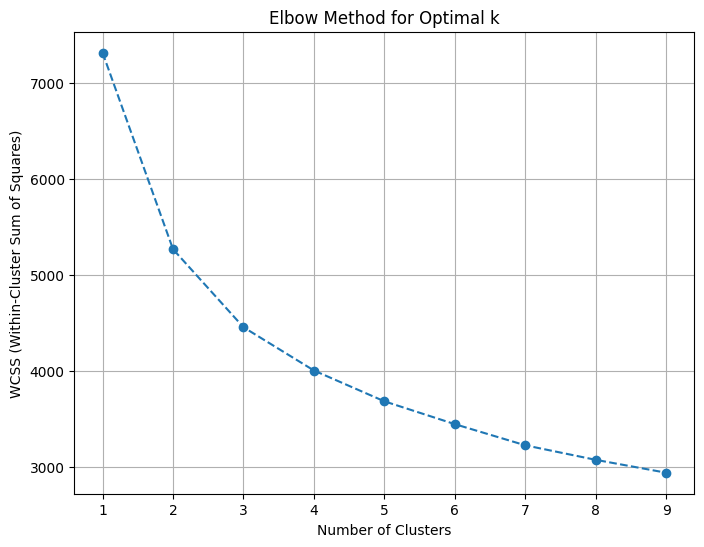

In [109]:
data = expression

# List to store WCSS for each number of clusters
wcss = []

# Loop over possible values of k (number of clusters)
for num_clusters in range(1, 10):  # You can adjust the range based on your data
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)  # WCSS is stored in inertia_

# Plot the Elbow plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, 10), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(np.arange(1, 10))
plt.grid(True)
plt.show()

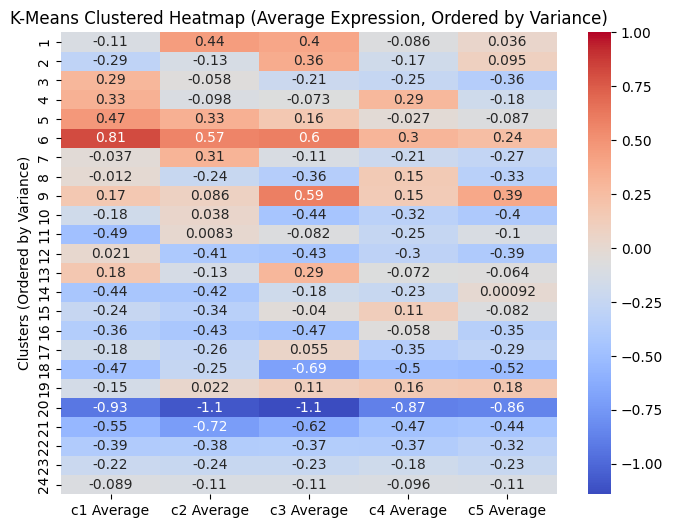

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# data = expression
# Filter only columns containing "Average" BEFORE clustering
average_data = data.loc[:, data.columns.str.contains("Average")].copy()

# Number of clusters
num_clusters = 24

# Run KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=100)
clusters = kmeans.fit_predict(average_data)

# Add cluster labels to the filtered data
average_data["Cluster"] = clusters

# Group by cluster and compute mean expression per cluster
clustered_data = average_data.groupby("Cluster").mean()

# Compute variance across columns for each cluster
cluster_variances = clustered_data.var(axis=1)

# Sort clusters by decreasing variance
sorted_clusters = cluster_variances.sort_values(ascending=False).index

# Create mapping from old cluster label to new label (ordered by variance)
cluster_mapping = {old: new for new, old in enumerate(sorted_clusters, start=1)}

# Apply new cluster label mapping
average_data["Cluster"] = average_data["Cluster"].map(cluster_mapping)

# Recompute cluster means using remapped cluster labels
clustered_data = average_data.groupby("Cluster").mean()

# Sort clustered_data rows by new cluster label (which is already ordered by variance)
clustered_data = clustered_data.loc[sorted(clustered_data.index)]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(clustered_data, cmap="coolwarm", xticklabels=True, yticklabels=True, annot=True, vmax=1)

plt.title("K-Means Clustered Heatmap (Average Expression, Ordered by Variance)")
plt.ylabel("Clusters (Ordered by Variance)")
plt.show()


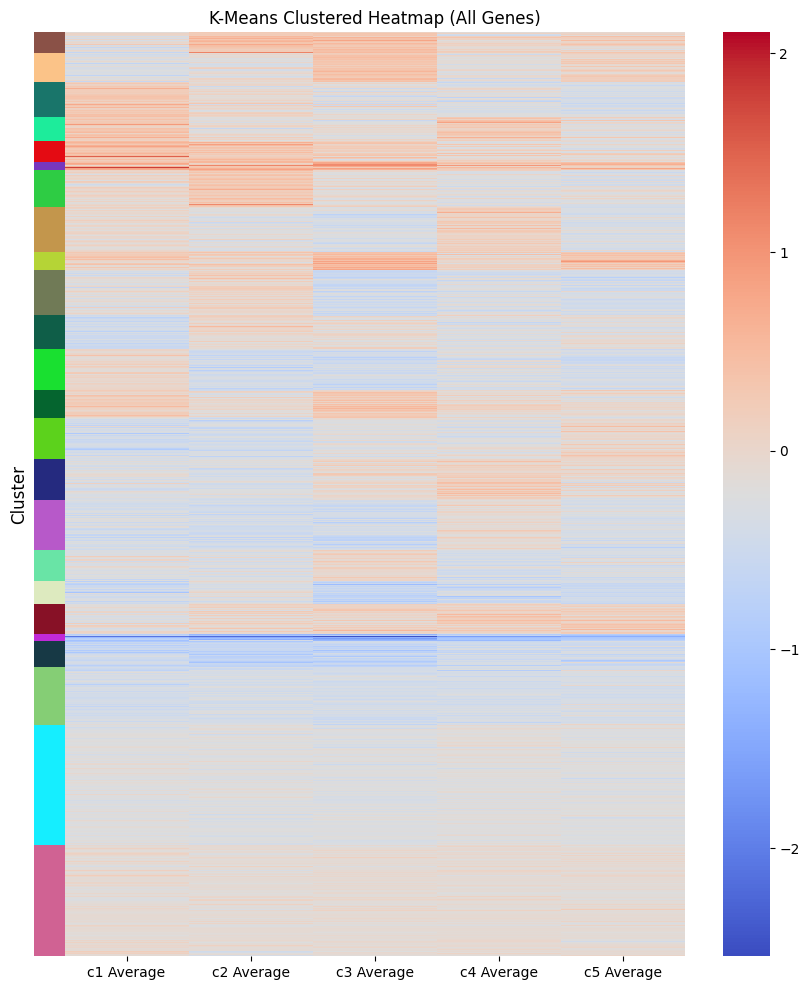

In [147]:
from matplotlib.colors import ListedColormap

# Reorder full dataset by new cluster labels
data_sorted = average_data.sort_values(by="Cluster")

# Get the number of unique clusters
num_clusters = data_sorted["Cluster"].nunique()

# Generate a random colormap for clusters
random_colors = np.random.rand(num_clusters, 3)  # Random RGB colors
cluster_cmap = ListedColormap(random_colors)  # Create colormap

# Create a figure for both heatmaps
plt.figure(figsize=(10, 12))

# Create a main heatmap for the data (without the cluster column)
sns.heatmap(data_sorted.drop(columns=["Cluster"]), cmap="coolwarm", xticklabels=True, yticklabels=False)

# Create an inset axis for the color bar (cluster labels)
cbar_ax = plt.gca().inset_axes([-0.05, 0, 0.05, 1])  # Thin vertical color bar on the left side

# Plot the cluster labels as a heatmap on the left side using the random colormap
sns.heatmap(data_sorted[['Cluster']], cmap=cluster_cmap, cbar=False, xticklabels=False, yticklabels=False, ax=cbar_ax)

# Add y-axis label for the inset color bar
cbar_ax.set_ylabel('Cluster', fontsize=12)

# Remove any index column label (this is likely where "Unnamed: 0" comes from)
plt.gca().set_ylabel("")  # This removes the y-axis label on the second heatmap

# Adjust layout and finalize the plot
plt.title("K-Means Clustered Heatmap (All Genes)")
plt.show()

In [148]:
# Getting rid of semi-colons for Enrichr

list_of_clusters = []
for cluster_num in range(1, num_clusters + 1): 
    genes_in_cluster = average_data[average_data["Cluster"] == cluster_num].index.to_list()
    list_of_clusters.append(genes_in_cluster)
    
j = 1
for cluster in list_of_clusters:
    i = 0
    while i < len(cluster):
        if ';' in cluster[i]:
            split_genes = cluster[i].split(';')
            cluster[i:i+1] = split_genes  # Replace the original gene with the split genes
            i += len(split_genes) - 1  # Skip over the new elements added
        i+=1
#     print(f"Cluster {j}:")
#     print(cluster)
    print(f"Cluster {j} length: " + str(len(cluster)))
    j+=1
    

Cluster 1 length: 410
Cluster 2 length: 574
Cluster 3 length: 695
Cluster 4 length: 480
Cluster 5 length: 430
Cluster 6 length: 160
Cluster 7 length: 730
Cluster 8 length: 889
Cluster 9 length: 360
Cluster 10 length: 897
Cluster 11 length: 682
Cluster 12 length: 809
Cluster 13 length: 570
Cluster 14 length: 810
Cluster 15 length: 816
Cluster 16 length: 1003
Cluster 17 length: 617
Cluster 18 length: 452
Cluster 19 length: 599
Cluster 20 length: 139
Cluster 21 length: 511
Cluster 22 length: 1162
Cluster 23 length: 2389
Cluster 24 length: 2213


# Over-representation Analysis

In [149]:
import gseapy as gp
# human = gp.get_library_name(organism='Human')

# for geneset_library in human:
#     if "hallmark" in geneset_library.lower():
#         print(geneset_library)

# library = gp.get_library(name="GO_Biological_Process_2025", organism="Human")
# print(library.keys())

In [164]:
from IPython.display import display, HTML

cluster = list_of_clusters[5]
print(f"Cluster size: {len(cluster)}")
print()
print(cluster)

enr = gp.enrich(gene_list=cluster, # or gene_list=glist
                 gene_sets=["data/bp_2024.gmt", "data/cc_2024.gmt", "data/mf_2024.gmt", "data/hallmark_2024.gmt", "data/onc_2024.gmt", "data/im_2024.gmt"], # kegg is a dict object
                 background=data.index.to_list(),
                 outdir=None,
                 verbose=False)

display(HTML(enr.results.loc[enr.results["Adjusted P-value"] < 0.05].sort_values(by='Adjusted P-value').to_html()))

Cluster size: 160

['ABCC5', 'ANKRD13D', 'ANKRD46', 'AP1S1', 'ARHGAP39', 'ARMC1', 'ATP6V1C1', 'ATXN2L', 'AURKA', 'AXIN1', 'AZIN1', 'BPGM', 'GID8', 'MRGBP', 'XXYLT1', 'FAM220A', 'C8orf33', 'NDUFAF6', 'C8orf76', 'FAM219A', 'CABLES2', 'CBX1', 'CDK16', 'CHCHD3', 'CHMP4C', 'CHRAC1', 'CLCN2', 'CLDN15', 'COPS5', 'CPLX1', 'CRTC2', 'CSPP1', 'CUL1', 'CYTH2', 'DCAF13', 'DECR1', 'DERL1', 'DFFB', 'DHX35', 'DSCC1', 'DUSP12', 'DVL3', 'ENSA', 'ENY2', 'ESRP1', 'FAM189B', 'RMDN1', 'FAM83H', 'FAM91A1', 'FBXL6', 'FBXO43', 'FTSJ2', 'GIGYF1', 'GNA12', 'GRINA', 'GTPBP2', 'HDAC7', 'HNRNPA2B1', 'HSF1', 'IFT81', 'INPP5E', 'INTS8', 'IRAK1', 'JRK', 'CEP170B', 'KIAA1429', 'KRIT1', 'LRCH4', 'LRRC14', 'MAL2', 'MCM7', 'MGAT4B', 'MTBP', 'MTDH', 'MTERF3', 'MTFR1', 'MUS81', 'NAA40', 'TONSL', 'NPIPA1', 'NSMCE2', 'NUDCD1', 'NUPL2', 'OSGIN2', 'OTUD6B', 'PABPC1', 'PDAP1', 'PLCB3', 'POLR2K', 'PPP2R5B', 'PTCD1', 'PTDSS1', 'PTK2', 'PTPN12', 'RAB11FIP3', 'RAD21', 'RAD54B', 'RALA', 'RBM12B', 'RELL2', 'RHEB', 'RHPN1', 'RIPK2', 'R

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
3834,im_2024.gmt,GSE18804_BRAIN_VS_COLON_TUMORAL_MACROPHAGE_DN,19/175,9.279237e-16,3.690353e-12,15.915860,550.904942,FAM91A1;YWHAZ;NDUFAF6;TRMT12;ZNF696;RNF139;DSCC1;CHMP4C;SLC25A32;SCRIB;COPS5;NUDCD1;DCAF13;RAD21;INTS8;NSMCE2;C8orf76;PABPC1;UBR5
6069,im_2024.gmt,GSE45365_CTRL_VS_MCMV_INFECTION_NK_CELL_DN,17/167,9.558227e-14,1.900653e-10,14.650758,439.211973,DSCC1;NSMCE2;DCAF13;C8orf76;CHMP4C;SCRIB;PTK2;NDUFAF6;COPS5;TRMT12;RAD21;TERF1;ARMC1;RNF139;INTS8;ENY2;DERL1
6066,im_2024.gmt,GSE45365_CD8A_DC_VS_CD11B_DC_IFNAR_KO_DN,14/172,3.243466e-10,4.299755e-07,11.285462,246.578412,TBC1D31;TAF2;FAM91A1;DCAF13;NSMCE2;ZNF16;CHMP4C;PTK2;NDUFAF6;RAD21;ZFAND1;RNF139;ENSA;TATDN1
172,bp_2024.gmt,GOBP_CELL_CYCLE,35/1518,7.553753e-08,1.438990e-04,3.193354,52.366650,TMEM67;OSGIN2;TERF1;RHEB;SUN1;ENSA;RTEL1;DSCC1;CABLES2;MRGBP;WDR5;CHMP4C;SCRIB;COPS5;YEATS2;MTBP;RMDN1;CUL1;PPP2R5B;DCAF13;WRAP73;RRS1;RAB11FIP3;RAD21;CSPP1;NSMCE2;TAF2;UIMC1;ZNF16;RAD54B;CDK16;FBXO43;AURKA;HSF1;MUS81
1955,cc_2024.gmt,GOCC_CHROMOSOMAL_REGION,14/350,2.371153e-06,7.943362e-04,5.263382,68.172028,DSCC1;NSMCE2;CHMP4C;HNRNPA2B1;CBX1;RAD21;MTBP;TERF1;SUN1;MCM7;AURKA;RTEL1;HSF1;CHRAC1
2187,cc_2024.gmt,GOCC_SAGA_TYPE_COMPLEX,5/35,1.231035e-05,2.061983e-03,21.106478,238.610224,TAF2;WDR5;YEATS2;ENY2;TAF4
914,bp_2024.gmt,GOBP_ORGANELLE_FISSION,16/460,2.710458e-06,2.581711e-03,4.569144,58.569081,NSMCE2;WRAP73;DCAF13;RRS1;CHMP4C;RAD54B;RAD21;MTBP;FBXO43;MTFR1;TERF1;SUN1;AURKA;MUS81;RMDN1;RALA
3880,im_2024.gmt,GSE19401_PAM2CSK4_VS_RETINOIC_ACID_STIM_FOLLICULAR_DC_UP,10/189,6.215459e-06,6.179721e-03,7.016195,84.113448,ZKSCAN5;PPP2R5B;MRGBP;LRCH4;ABCC5;COPS5;RAD21;PTCD1;UBE2W;RMDN1
1232,bp_2024.gmt,GOBP_PROTEIN_DNA_COMPLEX_ORGANIZATION,20/761,1.040180e-05,6.605144e-03,3.441468,39.485795,TERF1;MRGBP;WDR5;CBX1;YEATS2;CHRAC1;DCAF13;RAD21;AXIN1;TONSL;NSMCE2;TAF2;UIMC1;RAD54B;HDAC7;NAA40;UBR5;ENY2;AURKA;TAF4
1356,bp_2024.gmt,GOBP_REGULATION_OF_CELL_CYCLE,23/1016,2.399323e-05,1.142677e-02,2.965320,31.544300,TMEM67;TERF1;RHEB;CABLES2;MRGBP;WDR5;CHMP4C;SCRIB;COPS5;YEATS2;MTBP;PPP2R5B;RAB11FIP3;RAD21;CSPP1;NSMCE2;UIMC1;ZNF16;CDK16;FBXO43;AURKA;HSF1;MUS81


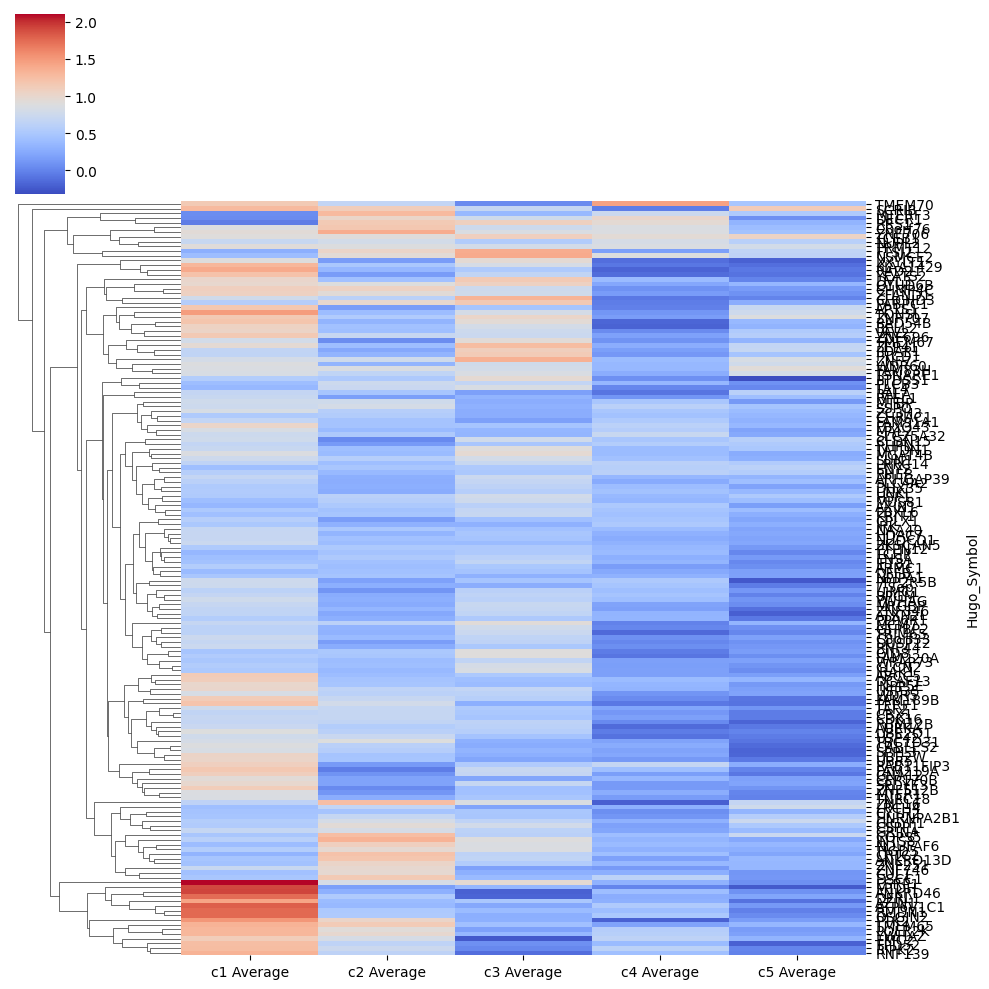

In [165]:
sns.clustermap(data_sorted.loc[cluster].drop(columns=["Cluster"]), cmap="coolwarm", xticklabels=True, yticklabels=True, annot=False, col_cluster = False)


In [166]:
adjusted_c1.columns = ["1"] * len(adjusted_c1.columns)
adjusted_c2.columns = ["2"] * len(adjusted_c2.columns)
adjusted_c3.columns = ["3"] * len(adjusted_c3.columns)
adjusted_c4.columns = ["4"] * len(adjusted_c4.columns)
adjusted_c5.columns = ["5"] * len(adjusted_c5.columns)
print(adjusted_c1.head())

                  1       1       1       1       1       1       1       1  \
Hugo_Symbol                                                                   
UBE2Q2P2    -0.5443  0.0453 -0.0651  0.9005  0.0184  0.0184 -0.7704 -0.6849   
SSX9        -0.0474 -0.0474 -0.0474 -0.0474 -0.0474 -0.0474 -0.0474 -0.0474   
EZHIP       -0.0684 -0.5459 -0.2836 -0.7616 -0.1523 -0.7616 -0.3635 -0.1523   
EFCAB8      -0.4290 -0.1805 -0.4290 -0.2365 -0.2111  0.6982  0.2590 -0.4290   
SDR16C6P    -0.1839 -0.1839 -0.1839 -0.1839 -0.1839 -0.1839 -0.1839 -0.1839   

                  1        1       1        1       1       1       1       1  \
Hugo_Symbol                                                                     
UBE2Q2P2     0.7732  0.01090  0.5387 -0.22340  0.0259  0.5946 -0.0795  0.9356   
SSX9        -0.0474 -0.04740 -0.0474 -0.04740 -0.0474 -0.0474 -0.0474 -0.0474   
EZHIP       -0.3227 -0.10640  0.1717 -0.76160 -0.1523 -0.0951 -0.3083 -0.1982   
EFCAB8       0.3296 -0.03595  0.1086 -0.0

c:\Users\tkhan0770\Documents\Dr_Hussain_Lab_Repos\.conda\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


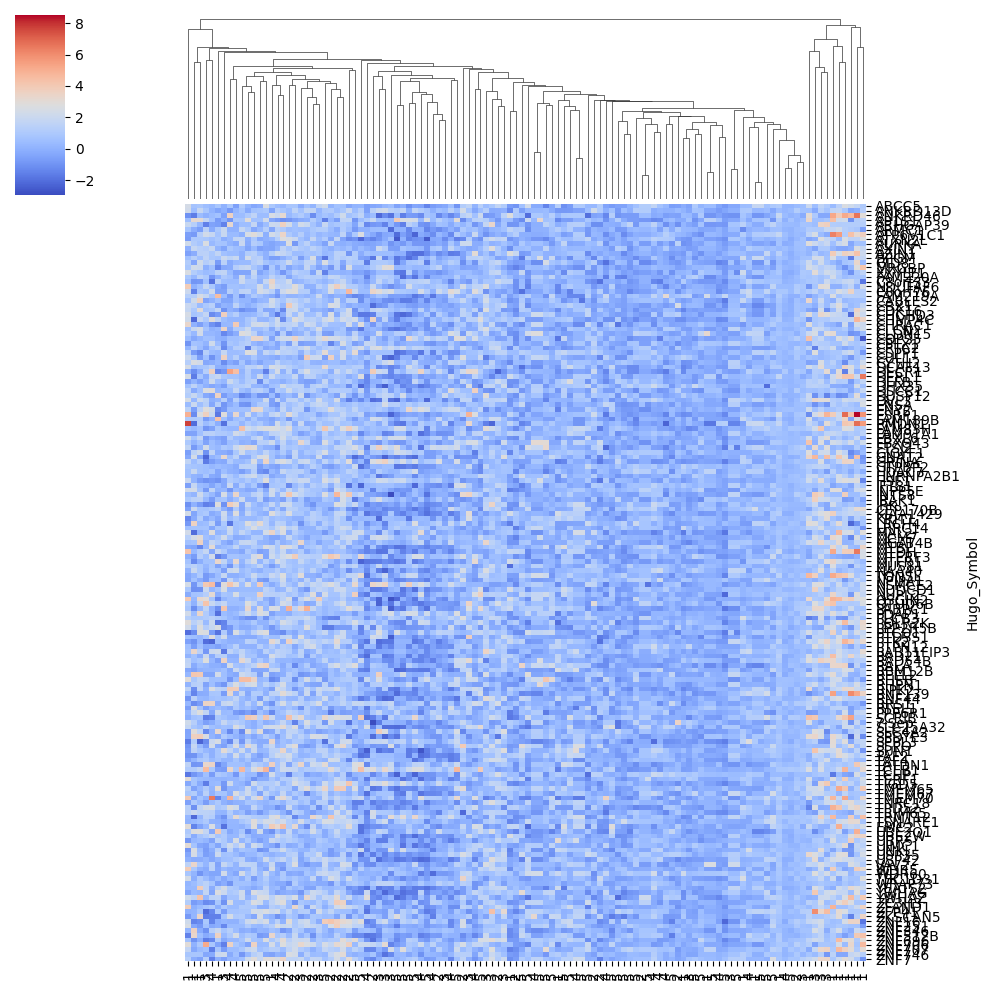

In [167]:
parent_bchem = pd.DataFrame()
parent_bchem = pd.concat([adjusted_c1, adjusted_c2, adjusted_c3, adjusted_c4, adjusted_c5], axis = 1)
drop_cols = [col for col in parent_bchem.columns if "Average" in col]
parent_bchem = parent_bchem.drop(columns = drop_cols, axis=1)
# print(parent_bchem.head())
sns.clustermap(parent_bchem.loc[cluster], cmap="coolwarm", xticklabels=True, yticklabels=True, annot=False, row_cluster=False)

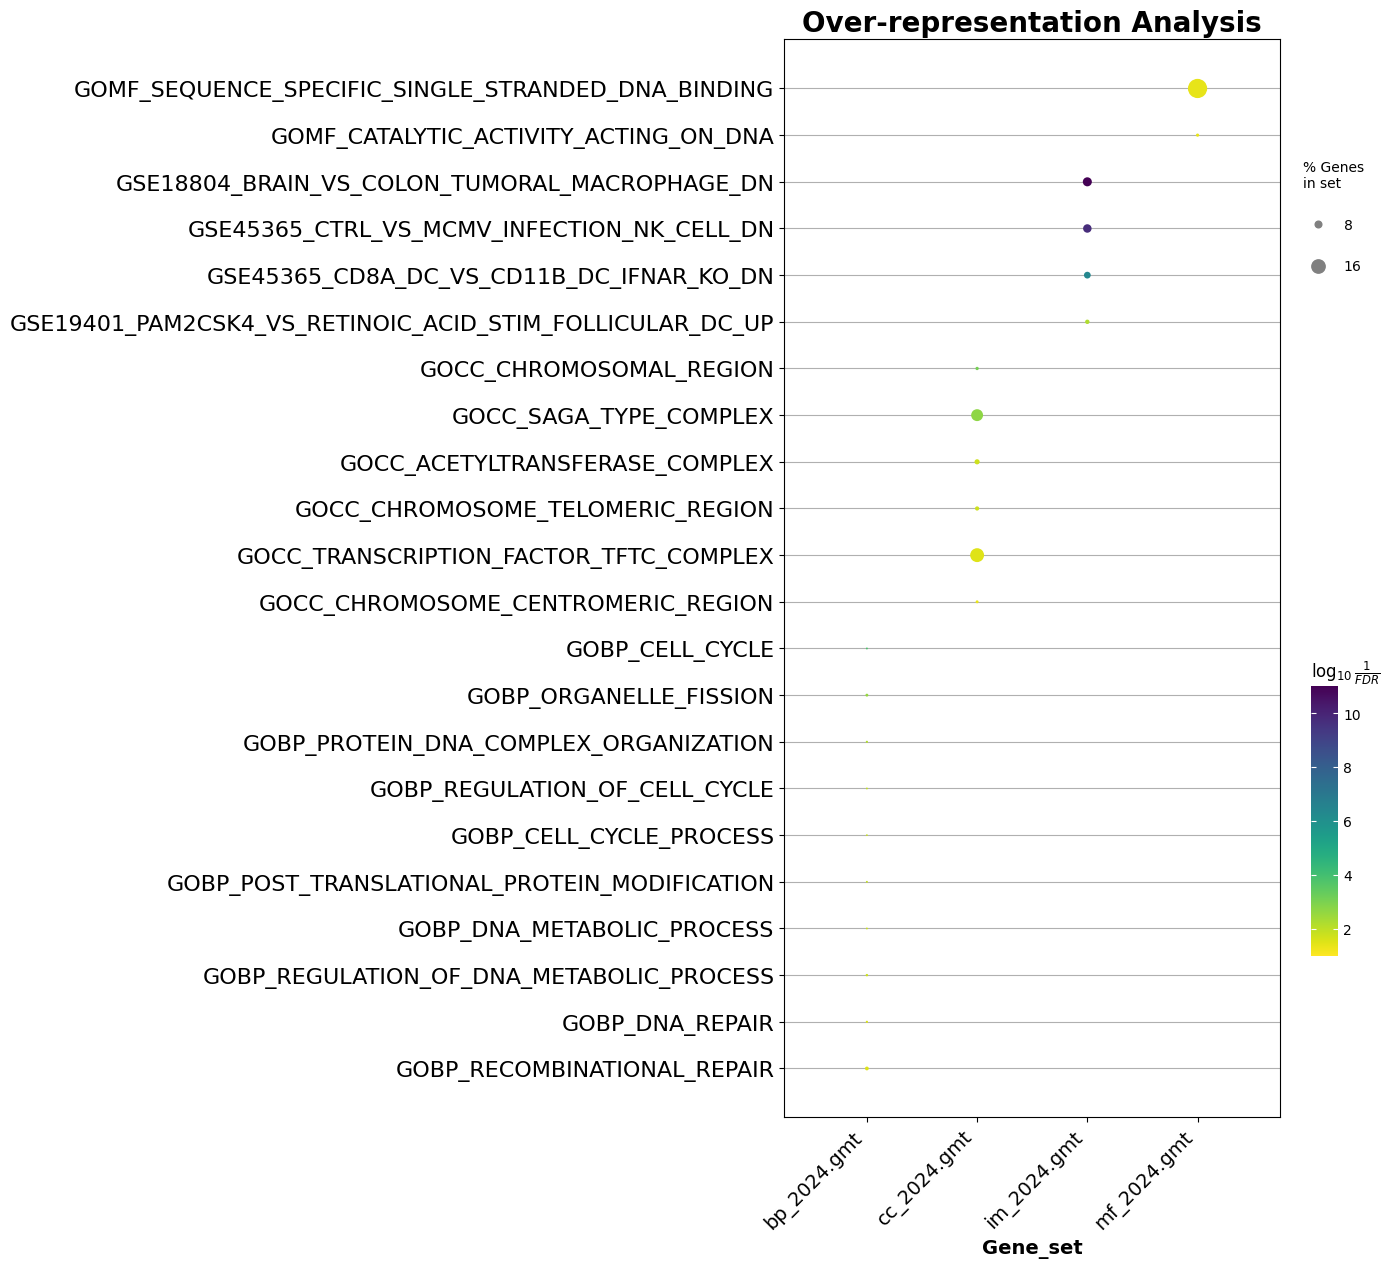

In [168]:
from gseapy import barplot, dotplot
ax = dotplot(enr.results,
              column="Adjusted P-value",
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=10,
              top_term=10,
              figsize=(8,14),
              title = "Over-representation Analysis",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=False, # set to False to revmove outer ring
              marker='o',
             )

In [169]:
parent_bchem_T = parent_bchem.loc[cluster].T
print(parent_bchem_T.head())
# # Remove columns with repeated names
# total_data = data.loc[:, ~parent_bchem.columns.duplicated()]

# # Drop non-numeric columns (assuming the first 3 columns are metadata)
# gene_expression = total_data.iloc[:, 0:]  # Exclude the label column

# Convert to numpy array
parent_bchem_T_vals = parent_bchem_T.values

print(parent_bchem_T_vals)

Hugo_Symbol   ABCC5  ANKRD13D  ANKRD46   AP1S1  ARHGAP39   ARMC1  ATP6V1C1  \
1           -0.7252   -1.2668   2.7683  0.4290   -0.9828  1.6491    0.6720   
1            0.8817   -0.4295   0.6315 -0.7396   -0.6482  0.9151    0.7086   
1            1.3921   -0.8180   0.1717 -1.2547   -0.0961  1.2287    0.2885   
1            0.9444   -0.4305   2.5565 -0.3818    2.0936 -0.3107    2.3385   
1           -0.1557    0.0651   0.3805 -0.2620    0.1426  0.2403    0.1137   

Hugo_Symbol  ATXN2L   AURKA   AXIN1  ...  ZKSCAN5   ZNF16  ZNF251  ZNF346  \
1           -0.9229  0.1335 -1.1616  ...  -0.3600  0.3921 -0.3909 -1.2442   
1            0.9326  0.7525  0.1027  ...  -1.5514 -0.1121 -0.0536  1.9359   
1            0.9568  0.1259  0.2947  ...   1.8570  0.8394  1.2205  0.1469   
1            0.2778 -0.4004 -0.4240  ...  -0.0036  0.3586  1.2555  0.6150   
1           -0.7660 -1.0390 -0.3137  ...   1.0104 -0.2330  0.2909 -0.0893   

Hugo_Symbol  ZNF512B  ZNF696  ZNF706  ZNF707  ZNF746    ZNF7  
1    

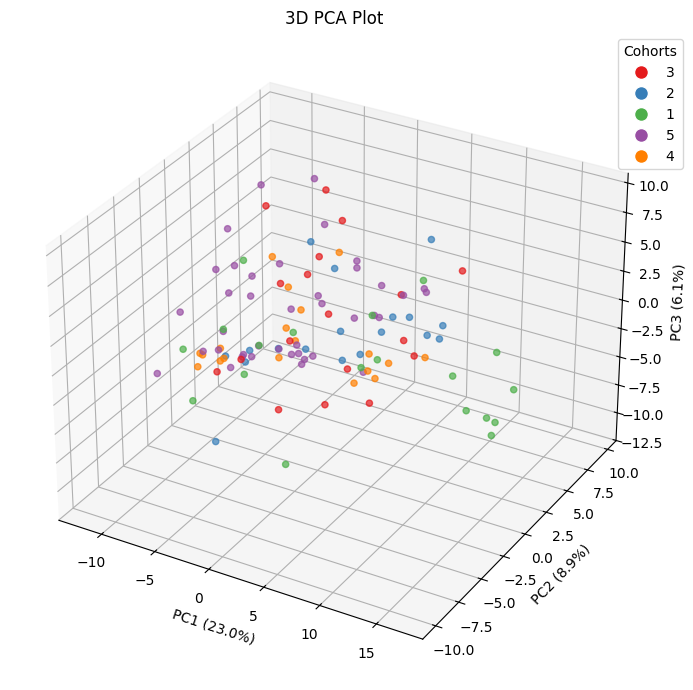

In [170]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Perform PCA
pca = PCA(n_components=3)
gene_expression_pca = pca.fit_transform(parent_bchem_T_vals)

# Get % variance explained
explained_var = pca.explained_variance_ratio_ * 100  # convert to percent

# Get cohort labels
cohorts = parent_bchem.columns
unique_labels = list(set(cohorts))
color_map = {label: color for label, color in zip(unique_labels, plt.cm.Set1.colors)}
colors = cohorts.map(color_map)

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot PCA
scatter = ax.scatter(
    gene_expression_pca[:, 0],
    gene_expression_pca[:, 1],
    gene_expression_pca[:, 2],
    c=colors, alpha=0.7
)

ax.set_xlabel(f'PC1 ({explained_var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_var[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_var[2]:.1f}%)')
ax.set_title('3D PCA Plot')

# Legend
legend_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color)
    for label, color in color_map.items()
]
ax.legend(handles=legend_patches, title='Cohorts', loc='best', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


C:\Users\tkhan0770\AppData\Local\Temp\ipykernel_36912\2152845138.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap("Set1", len(unique_labels))


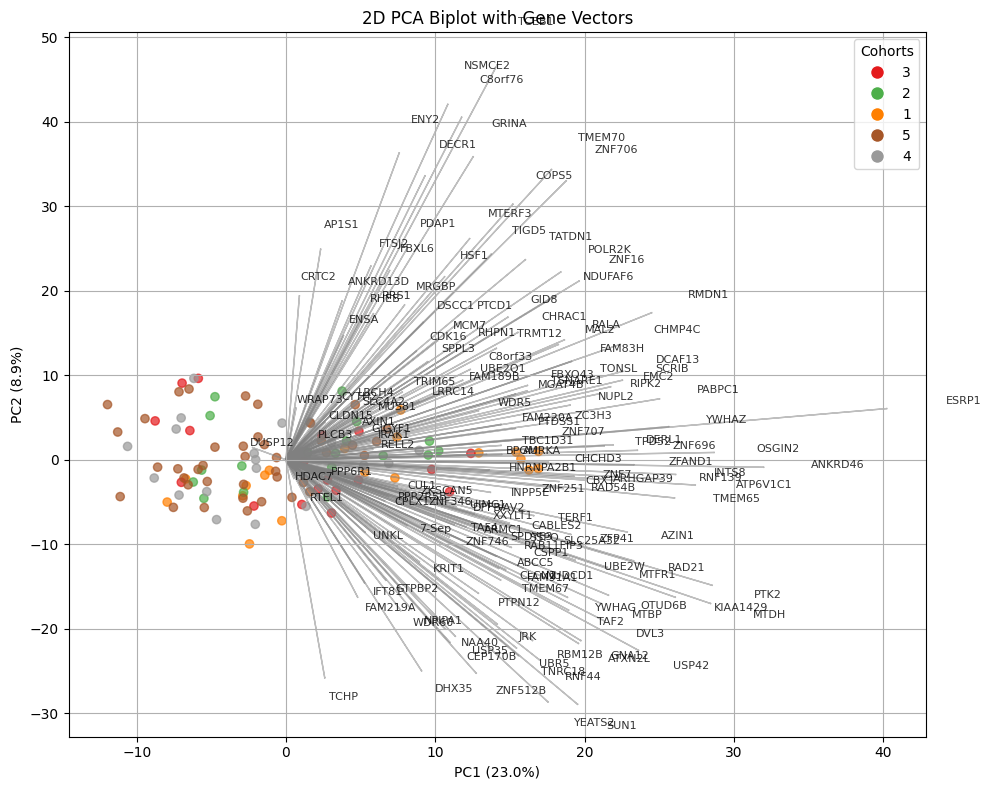

In [171]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# Run PCA on the transposed data (samples as rows)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(parent_bchem_T_vals)

# Get variance explained
explained_var = pca.explained_variance_ratio_ * 100

# Get cohorts and assign high-contrast colors
cohorts = parent_bchem.columns
unique_labels = list(set(cohorts))
colormap = plt.cm.get_cmap("Set1", len(unique_labels))
color_map = {label: colormap(i) for i, label in enumerate(unique_labels)}
colors = cohorts.map(color_map)

# Plot 2D scatter plot with PCA results
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], c=colors, alpha=0.7)

# Axis labels
ax.set_xlabel(f'PC1 ({explained_var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_var[1]:.1f}%)')
ax.set_title('2D PCA Biplot with Gene Vectors')

# Add gene vectors (loadings)
loadings = pca.components_.T  # shape: (n_genes, 2)
genes = parent_bchem_T.columns  # gene names

# Scale vectors for visibility
scale_factor = 200

for i, gene in enumerate(genes):
    ax.arrow(0, 0, 
             loadings[i, 0] * scale_factor, 
             loadings[i, 1] * scale_factor, 
             color='gray', alpha=0.5, head_width=0.05)
    ax.text(loadings[i, 0] * scale_factor * 1.1, 
            loadings[i, 1] * scale_factor * 1.1, 
            gene, fontsize=8, alpha=0.8)

# Custom legend
legend_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label=label, 
               markersize=10, markerfacecolor=color)
    for label, color in color_map.items()
]
ax.legend(handles=legend_patches, title='Cohorts', loc='best')

plt.grid(True)
plt.tight_layout()
plt.show()


In [172]:
print(len(parent_bchem.columns))

# print the top 10 genes that contribute to pc1

# Get the loadings for PC1
pc1_loadings = pca.components_[0]

# Create a DataFrame with genes and their corresponding loadings
pc1_contributions = pd.DataFrame({
    'Gene': parent_bchem_T.columns,
    'Contribution': pc1_loadings
})

# Sort by absolute contribution and get the top 10 genes
top_10_genes = pc1_contributions.reindex(pc1_contributions.Contribution.abs().sort_values(ascending=False).index).head(10)

print(top_10_genes)


114
         Gene  Contribution
44      ESRP1      0.200999
2     ANKRD46      0.159791
83     OSGIN2      0.143222
92       PTK2      0.142552
73       MTDH      0.142056
6    ATP6V1C1      0.136899
61      INTS8      0.130326
65   KIAA1429      0.130239
123    TMEM65      0.129969
146     YWHAZ      0.127990


2025-07-23 13:16:05,980 [WARNING] Duplicated values found in preranked stats: 6.73% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,tag %,gene %,fdr,es,nes,lead_genes
0,onc_2024.gmt__TBK1.DN.48HRS_UP,30/49,25.16%,0.005985,0.524254,1.811665,PTK2;UBQLN2;COPB2;OXSR1;DDR1;MTFR1;TEX10;MAP3K4;TP53BP1;CNOT4;SDHB;PIK3C2B;APPBP2;RBM15B;TMCO1;P4HTM;PSRC1;RNMT;SLC11A2;IGFBP3;CHMP6;TM9SF2;BAMBI;ZMIZ1;MYCBP;UBE2J1;CNDP2;APOE;ARL4C;ECD
1,onc_2024.gmt__TBK1.DF_DN,108/264,22.19%,0.005985,0.411356,1.740525,ATP6V1C1;ZC2HC1A;PRRC2B;ZWINT;UBE2W;CXADR;RALA;TCAF1;RSRC1;CCNE2;PKP4;MPHOSPH9;TFAM;KTN1;ATG2B;RXRA;TBC1D10B;KDM4A;GTPBP8;SLC25A13;ERLIN2;UBL4A;KIF3A;GOLGA2;IDE;MED13L;GNPDA1;ADCY6;MFSD6;ZNF654;ANKFY1;KIF14;KPNA6;RBBP5;NAA15;GALNT3;BPTF;ATP6AP2;PDHX;GALNT11;ADAM10;MBP;GNAI3;TSPAN5;MTPAP;GTF2A1;YES1;SCARB1;SPDL1;CD2AP;FNBP1L;PANK3;NME6;DNAJC16;UBXN4;ARMC1;VRK1;ZNF557;NF1;CLEC16A;CDCA4;RCC1;DNAJB14;EXOC5;RSF1;SEMA3C;DENND1B;TBK1;ITCH;C5orf22;ZNHIT6;LETM1;SMURF2;ALDH9A1;HMGCS1;NAA35;MAOA;OSBPL1A;MSH2;NRIP1;USP46;SMARCA2;SIKE1;ZZZ3;RFWD3;RNF5;PMAIP1;EHF;MIS18BP1;DDX60;CDC27;LMNB1;RPS6KB1;TTPAL;CLOCK;SNX15;SOWAHC;AFF4;SLC35A5;RCBTB1;GOLGA4;MTA1;AGFG1;TAF15;THOC2;AKAP9;HOXA1;SUSD6
2,onc_2024.gmt__GCNP_SHH_UP_EARLY.V1_UP,62/161,20.61%,0.008978,0.437308,1.754091,AZIN1;TRAIP;SMC2;AURKA;TOP2B;RRM1;PRC1;VPS4B;CXorf38;TYMS;FAM220A;EPB41L4B;RPL39L;KIF4A;UBE2T;PHTF2;MCM5;CD276;KIF1A;MSH6;CDC23;PDS5B;SLC35E1;VHL;ADCY6;ANLN;STAG2;FNTB;MAPK14;KIF1B;SPDL1;TSHB;TOP2A;AURKB;MCM6;UPF3B;POLA2;MATR3;KIFC1;CLCN6;MCM10;SRSF10;XPO1;RBBP6;PARG;TNPO1;RYK;PUM2;CNOT2;LUC7L2;TMPRSS2;ZZZ3;GNL3;DOLPP1;RNF103;FOXK1;TBP;FEN1;E2F8;ANKRD13C;ZNF708;AFF4
3,onc_2024.gmt__RPS14_DN.V1_DN,70/177,21.70%,0.023942,0.394562,1.602615,ATAD2;THEM6;PRC1;TK1;KIF15;CCNB2;AGAP1;LARS2;TUBGCP4;KIF2C;GTF2H4;ESPL1;KIF20A;MCM5;MKI67;DLGAP5;KIF23;ERCC6L;ECT2;MYH10;GINS2;CENPE;INCENP;PLK1;USP5;LGR4;NUP155;POLD1;SLC29A2;ZWILCH;MYO19;MTPAP;PBK;CAD;TMSB15A;NDC1;ARHGAP11A;PYCR1;MANEA;COBLL1;SLC31A1;KCTD20;ASNS;NCAPH;MYBL2;APOOL;DOCK9;MCM10;MSH2;FBXO5;ZNF74;MYLIP;APOBEC3A;SLC29A1;PRMT3;PC;EXO1;EPCAM;PSAT1;E2F8;GATC;CDC20;GUF1;DNAJA4;TUBB2B;EPB41;ERCC2;TLN2;TLX2;IPO4
4,onc_2024.gmt__BCAT_GDS748_UP,15/43,17.17%,0.033727,-0.470295,-1.579367,GCH1;CEBPB;C3orf52;CASP9;UBE2N;HHEX;SRPX;ITGA9;AQP3;MSX2;COTL1;BAG3;LEF1;AOPEP;FAH
5,onc_2024.gmt__ESC_V6.5_UP_EARLY.V1_DN,66/150,24.72%,0.033727,-0.410244,-1.817422,BCL3;CDC42EP1;CALML4;NAB2;HES7;PCOLCE;SOCS3;FHL2;CCDC80;ANXA5;COL16A1;SERPINE1;SMARCD3;STARD8;SERPINF2;LOXL1;SLC41A3;BHLHE40;ZFP36L1;TUBB6;NID1;FGF2;JUNB;MGP;S100A6;ESRRA;TNC;CSRP1;IGFBP7;AQP3;GSTP1;TFEB;ANXA2;HTRA1;GJB5;GJB3;AXL;SCARA3;GBP2;HBEGF;AEBP1;C16orf74;CAV1;TAGLN;NTN1;EMP1;TGFB1I1;DDHD1;LAMC2;KLK10;FGF17;ANXA1;BGN;FBXO28;ANXA3;SERPINF1;CADPS;TGM1;KIT;PMP22;CFB;CARD14;PLCL2;GAP43;ALX3;S100A4
6,onc_2024.gmt__KRAS.BREAST_UP.V1_UP,38/131,27.28%,0.036538,-0.388230,-1.587395,OSGIN1;TAPT1;NDUFA4L2;SOX17;SPRY2;CCL16;PDE2A;ANO2;IL1RL1;KCNJ14;PPP1R15A;TRAF1;OR2C1;GPR37L1;NPAS1;LYL1;A2M;IL37;NRL;SAMD14;NFE2;CYB5R2;PCDHGA11;KCNAB3;CASS4;KRT34;LIF;IL13RA2;CDSN;STC1;RMST;KLK6;OCA2;ETV2;MAPK4;CEACAM1;CCL22;KCNK15
7,onc_2024.gmt__GCNP_SHH_UP_LATE.V1_UP,53/168,18.82%,0.037110,0.386946,1.557319,SMC2;AURKA;CDC25C;TOP2B;RRM1;PRC1;TK1;VPS4B;KIF2C;FANCC;PHTF2;MCM5;CDK1;DLGAP5;COPB1;RRM2;PLEKHA7;INCENP;NAA15;GALNT3;NUSAP1;TOP2A;PTCD3;SMC4;GART;AURKB;MCM4;MCM6;SDC2;SACM1L;POLA2;ARIH1;MATR3;UNG;EIF3A;KIFC1;PCNT;COIL;NPTX1;CLCN5;FOXA1;MCM10;SRSF10;XPO1;LIG1;USP39;RYK;PSMC3IP;PIK3CA;SLC29A1;GNL3;MIS18BP1;GFM2
8,onc_2024.gmt__AKT_UP.V1_DN,58/179,17.24%,0.040473,-0.384545,-1.603868,RMND1;G6PC2;STMP1;GNA14;SIX5;EXOSC1;C1R;ESR2;EFEMP2;C11orf71;CNN2;UPB1;SMARCD3;ASS1;PDLIM3;SERPINF2;ADHFE1;CSDC2;GALNT16;C1S;CAV2;ISLR;SNHG6;NID1;CDPF1;STAT5A;KRT5;MSRB2;HIC1;ZDHHC6;LTC4S;TSPAN4;ID3;ITIH5;DPT;SLC39A4;FMO3;HTRA1;CHST12;RPS6KB2;S1PR3;IFFO1;NAT8;ALPL;PDIA5;HPS1;GHR;TIMP3;COL17A1;KLF2;TNS2;SCARA3;OGN;KRT15;FAS;RAMP1;FAH;MATN2
9,onc_2024.gmt__CRX_DN.V1_DN,33/119,19.10%,0.042159,-0.404521,-1.654673,BCL3;NAB2;LAD1;CEBPB;PCOLCE;MYOCD;SOCS3;CEBPD;COL16A1;SMOC2;TECTA;SERPING1;SPG21;CAMK2B;TUBB6;TMOD1;JUNB;S100A6;EGR1;GNG11;ANXA2;FMO3;TIMP1;KLF10;S100A16;STEAP4;ZDHHC14

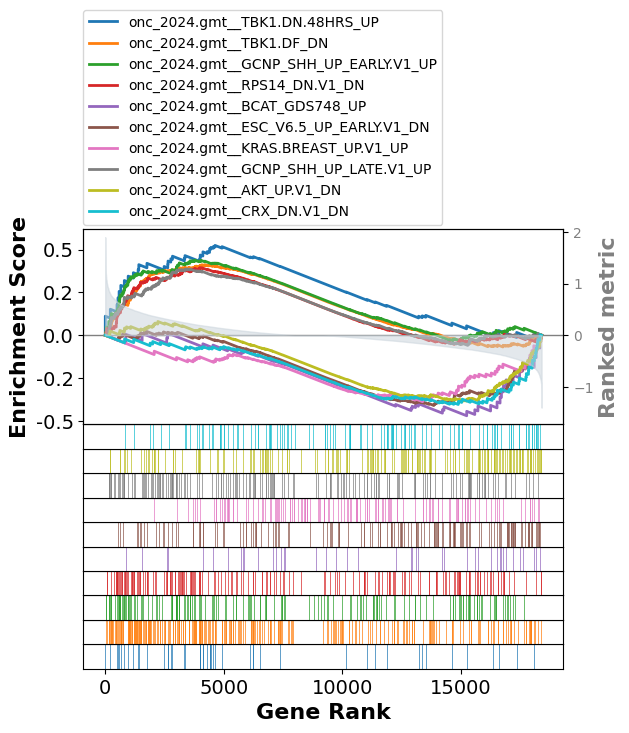

In [173]:
# Create a ranking metric - here using the difference between c4 and c1 averages
expression['ranking_metric'] =  expression['c1 Average'] - expression['c4 Average']

# Rank genes by this metric
ranking = expression[['ranking_metric']]
ranking = ranking.sort_values(by='ranking_metric', ascending=False)

# Convert to the format gseapy expects (index = gene names, column = ranking)
ranking = ranking.rename_axis("gene").reset_index()

import gseapy as gp

# Path to the gene sets file
gmt_file = "data/hallmark_2024.gmt"  # Update path as needed

pre_res = gp.prerank(rnk = ranking,
                     gene_sets=["data/onc_2024.gmt"], # kegg is a dict object
                     seed = 6, permutation_num = 100)

# gene_sets=["data/bp_2024.gmt", "data/cc_2024.gmt", "data/mf_2024.gmt", "data/hallmark_2024.gmt", "data/onc_2024.gmt", "data/im_2024.gmt"], # kegg is a dict object

out = []

for term in list(pre_res.results):
    out.append([term,
               pre_res.results[term]['tag %'],
               pre_res.results[term]['gene %'],
               pre_res.results[term]['fdr'],
               pre_res.results[term]['es'],
               pre_res.results[term]['nes'],
               pre_res.results[term]['lead_genes']])

out_df = pd.DataFrame(out, columns = ['Term', 'tag %', 'gene %', 'fdr', 'es', 'nes', 'lead_genes']).sort_values('fdr').reset_index(drop = True)
# display(HTML(out_df.to_html()))

axs = pre_res.plot(out_df['Term'][0:10],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

display(HTML(out_df.to_html()))


2025-07-23 13:16:11,055 [WARNING] Found duplicated gene names, values averaged by gene names!


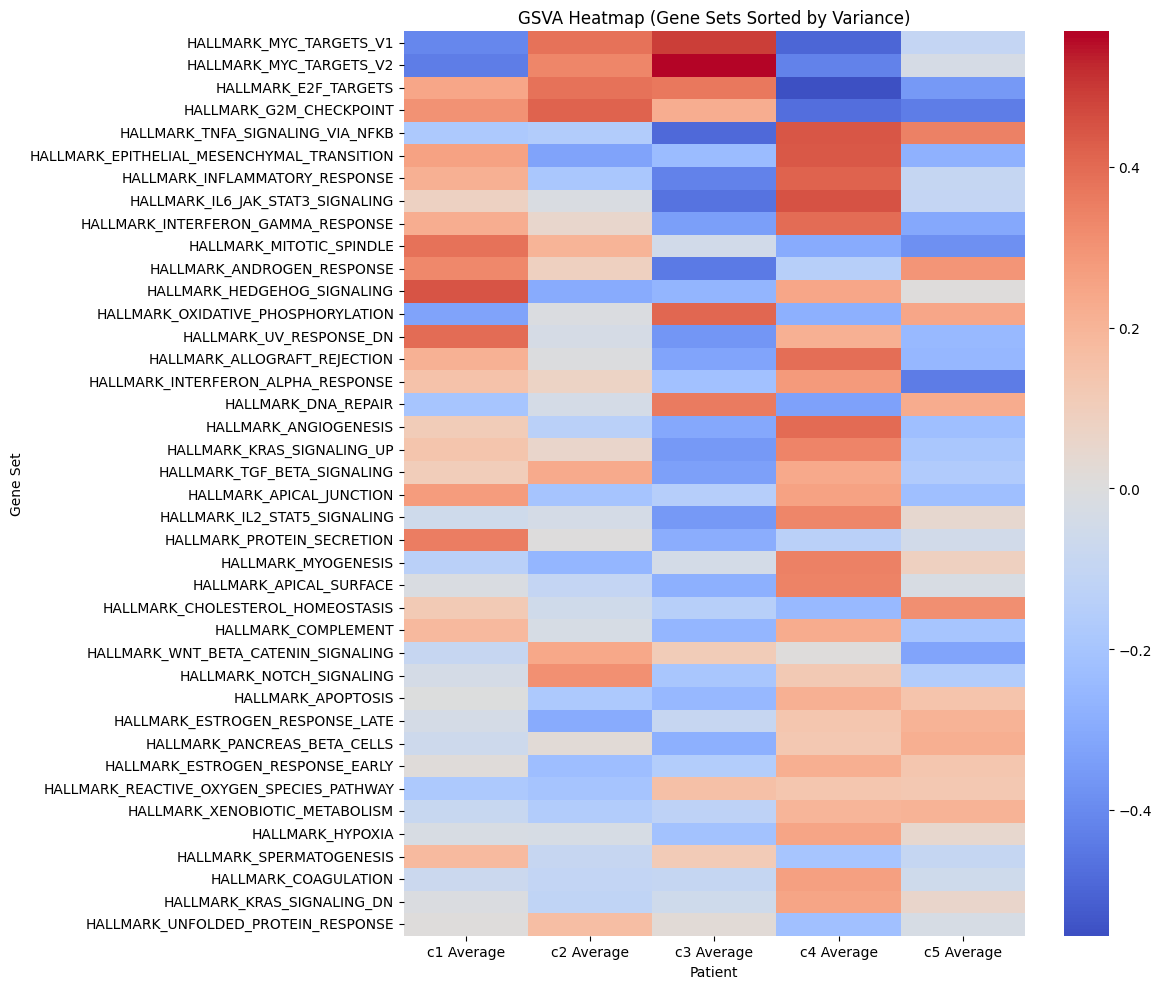

In [174]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gseapy as gp

# Drop metadata
original_expression = expression.drop(columns=["ranking_metric"])

# Run GSVA
es = gp.gsva(data=original_expression,
             gene_sets='data/hallmark_2024.gmt',
             outdir=None)

# Pivot to gene sets × patients matrix
es_matrix = es.res2d.pivot(index='Term', columns='Name', values='ES')

# Convert to float and drop NaNs just in case
es_matrix = es_matrix.astype(float).dropna(axis=0, how='any')

# Sort gene sets by row variance
es_matrix['Variance'] = es_matrix.var(axis=1)
es_matrix_sorted = es_matrix.sort_values(by='Variance', ascending=False).drop(columns='Variance')
top_n = 40
es_matrix_sorted = es_matrix_sorted.head(top_n)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(es_matrix_sorted, cmap='coolwarm', center=0)
plt.title("GSVA Heatmap (Gene Sets Sorted by Variance)")
plt.xlabel("Patient")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()


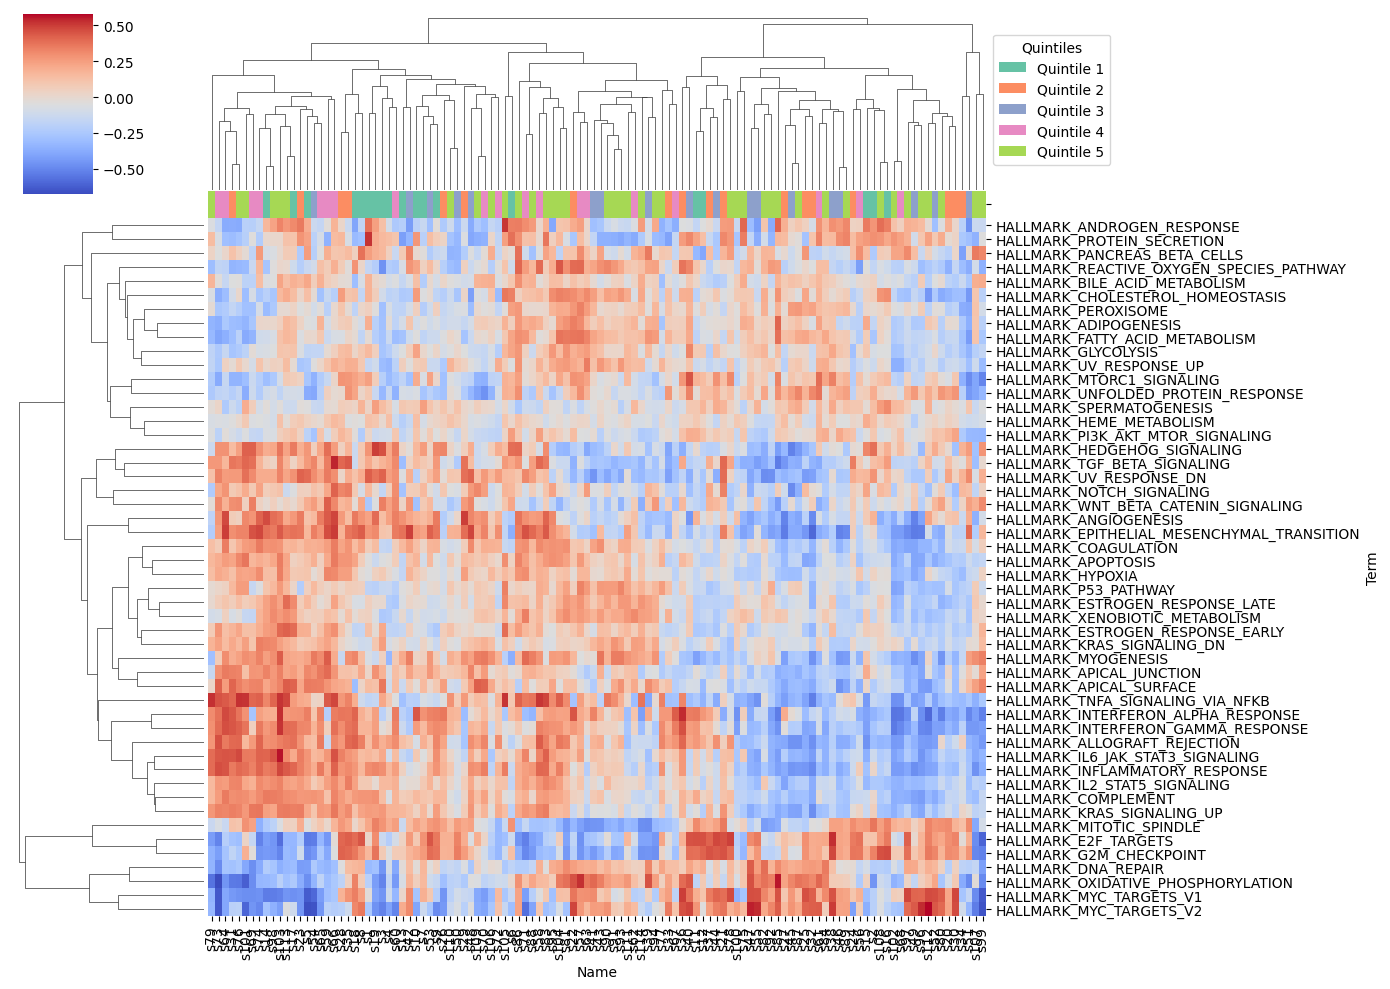

In [175]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import gseapy as gp

# Step 1: Rename columns to s1, s2, ..., sN
parent_bchem.columns = [f's{i+1}' for i in range(parent_bchem.shape[1])]

# Step 2: Create list of quartile labels matching sample order
# Assuming adjusted_c1 to adjusted_c4 were defined before and concatenated in that order:
quartile_labels = [1] * adjusted_c1.shape[1] + \
                  [2] * adjusted_c2.shape[1] + \
                  [3] * adjusted_c3.shape[1] + \
                  [4] * adjusted_c4.shape[1] + \
                  [5] * adjusted_c5.shape[1]

# Make sure length matches columns
assert len(quartile_labels) == parent_bchem.shape[1], "Mismatch in sample and quartile count!"

# Step 3: Map quartile labels to colors
quartile_palette = sns.color_palette("Set2", 5)
quartile_color_map = dict(zip([1, 2, 3, 4, 5], quartile_palette))
col_colors = pd.Series(quartile_labels, index=parent_bchem.columns).map(quartile_color_map)

# Step 4: Run GSVA (deduplicate first if needed)
parent_bchem = parent_bchem.groupby(parent_bchem.index).mean()

gsva_results = gp.gsva(data=parent_bchem,
                       gene_sets='data/hallmark_2024.gmt',
                       outdir=None)

# Step 5: Pivot GSVA result and convert to matrix
es_matrix = gsva_results.res2d.pivot(index='Term', columns='Name', values='ES')
es_matrix = es_matrix.astype(float).dropna(axis=0, how='any')

# Step 6: Plot clustermap with quartile annotations
g = sns.clustermap(
    es_matrix,
    cmap="coolwarm",
    xticklabels=True,
    yticklabels=True,
    annot=False,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    figsize=(14, 10)
)

# Add quartile legend
legend_elements = [
    Patch(facecolor=quartile_color_map[q], label=f'Quintile {q}') for q in sorted(quartile_color_map)
]
g.ax_col_dendrogram.legend(
    handles=legend_elements,
    title='Quintiles',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5)
)

plt.show()


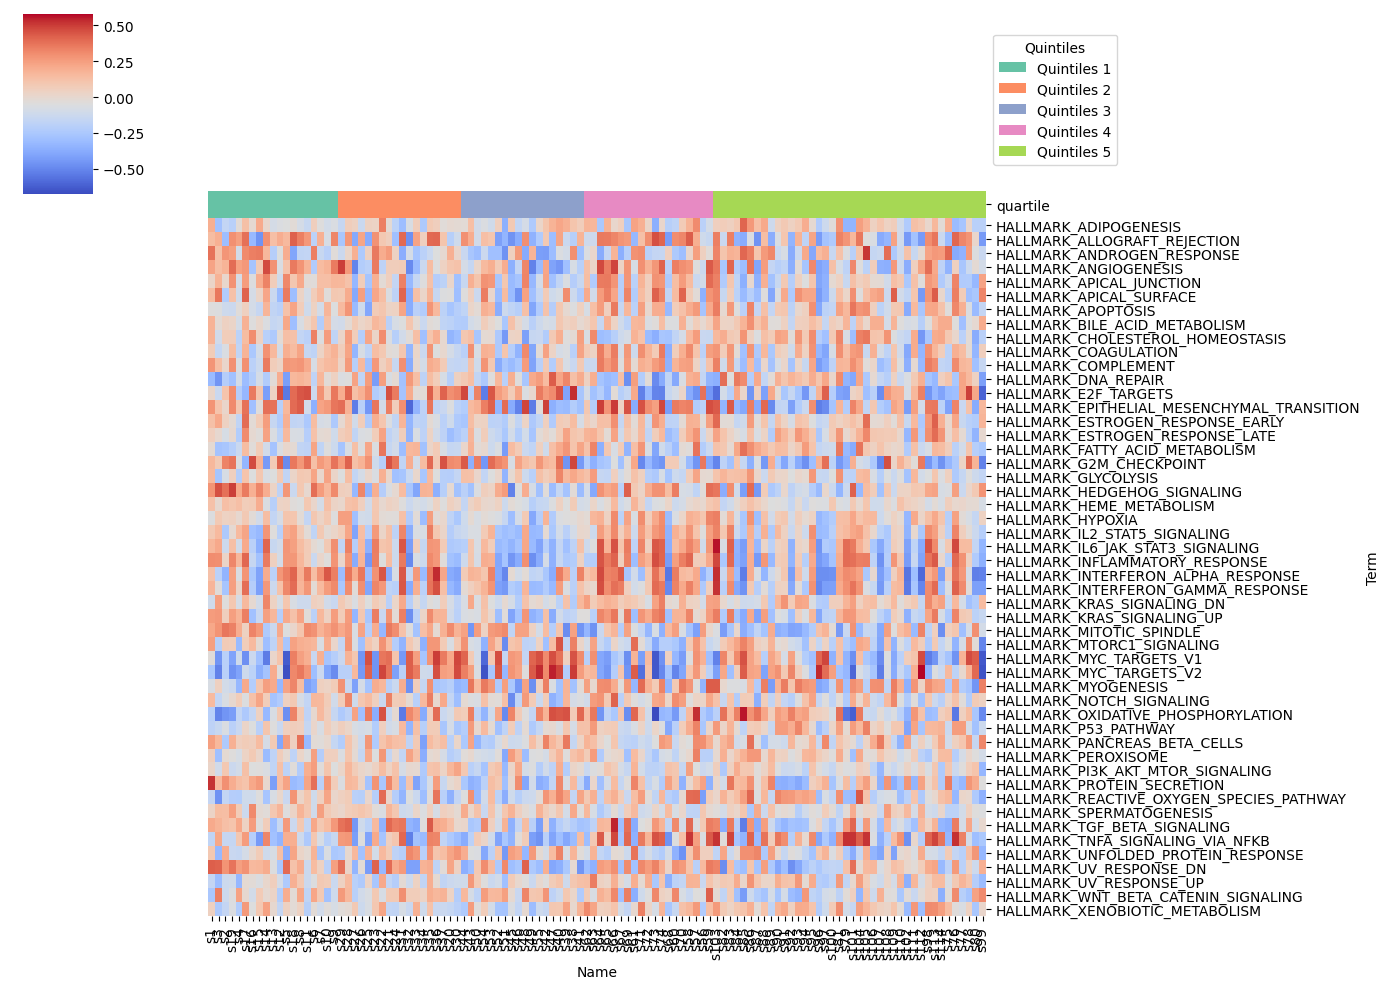

In [176]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import gseapy as gp

# Step 1: Rename columns to s1, s2, ..., sN
parent_bchem.columns = [f's{i+1}' for i in range(parent_bchem.shape[1])]

# Step 2: Generate quartile labels
quartile_labels = [1] * adjusted_c1.shape[1] + \
                  [2] * adjusted_c2.shape[1] + \
                  [3] * adjusted_c3.shape[1] + \
                  [4] * adjusted_c4.shape[1] + \
                  [5] * adjusted_c5.shape[1]

# Map quartiles to colors
quartile_palette = sns.color_palette("Set2", 5)
quartile_color_map = dict(zip([1, 2, 3, 4, 5], quartile_palette))
quartile_series = pd.Series(quartile_labels, index=parent_bchem.columns, name="quartile")
col_colors = quartile_series.map(quartile_color_map)

# Step 3: Deduplicate genes
parent_bchem = parent_bchem.groupby(parent_bchem.index).mean()

# Step 4: Run GSVA
gsva_results = gp.gsva(data=parent_bchem,
                       gene_sets='data/hallmark_2024.gmt',
                       outdir=None)

# Step 5: Extract GSVA matrix
es_matrix = gsva_results.res2d.pivot(index='Term', columns='Name', values='ES')
es_matrix = es_matrix.astype(float).dropna(axis=0, how='any')

# Step 6: Reorder columns by quartile
quartile_df = pd.DataFrame({
    "sample": es_matrix.columns,
    "quartile": quartile_series[es_matrix.columns].values
})
ordered_samples = quartile_df.sort_values("quartile")["sample"].tolist()

# Reorder matrix and colors
es_matrix = es_matrix[ordered_samples]
col_colors = col_colors[ordered_samples]

# Step 7: Plot WITHOUT clustering
g = sns.clustermap(
    es_matrix,
    cmap="coolwarm",
    xticklabels=True,
    yticklabels=True,
    annot=False,
    row_cluster=False,
    col_cluster=False,
    col_colors=col_colors,
    figsize=(14, 10)
)

# Step 8: Add quartile legend
legend_elements = [
    Patch(facecolor=quartile_color_map[q], label=f'Quintiles {q}') for q in sorted(quartile_color_map)
]
g.ax_col_dendrogram.legend(
    handles=legend_elements,
    title='Quintiles',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5)
)

plt.show()
